# Phase 6 - Model Evaluation & Comparison

## Objective

The objective of this phase is to evaluate the performance of all regression models using the same test dataset and identify the best-performing model.

### Evaluation Metrics

- Mean Absolute Error (MAE)
- Mean Squared Error (MSE)
- Root Mean Squared Error (RMSE)
- R² Score
- Adjusted R²
- Cross Validation Score

### Visualizations

- Actual vs Predicted
- Residual Plot
- Prediction Error Plot
- Feature Importance
- Model Comparison Chart

### Expected Outcome

Select the best regression model for deployment in the Flask web application.

In [13]:
# Import Libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [14]:
# Load Dataset
df=pd.read_csv("/home/aximsoft/Documents/EOWA/Week_08/Notebooks/dataset/house_prices_cleaned.csv")

df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,...,MoSold,YrSold,SaleType,SaleCondition,SalePrice,HouseAge,TotalBathrooms,TotalSF,TotalPorchArea,RemodeledHouse
0,1,4.110874,0.869742,1.646667,9.042040,0.526589,3,0.869742,0.0,0.959135,...,2,2008,1.162283,0.959135,208500,5,3.500000,15.552676,4.127134,0
1,2,3.044522,0.869742,1.685370,9.169623,0.526589,3,0.869742,0.0,0.741276,...,5,2007,1.162283,0.959135,181500,31,2.263295,9.238188,0.000000,0
2,3,4.110874,0.869742,1.655196,9.328212,0.526589,0,0.869742,0.0,0.959135,...,9,2008,1.162283,0.959135,223500,7,3.500000,15.647882,3.761200,1
3,4,4.262680,0.869742,1.631370,9.164401,0.526589,0,0.869742,0.0,0.000000,...,2,2006,1.162283,0.000000,140000,91,2.000000,15.530382,5.472023,1
4,5,4.110874,0.869742,1.694266,9.565284,0.526589,0,0.869742,0.0,0.741276,...,12,2008,1.162283,0.959135,250000,8,3.500000,16.089311,4.442651,0


In [15]:
# Import Libraries
import joblib

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [16]:
# Features and Target
X = df.drop("SalePrice",axis=1)
y = df["SalePrice"]

In [17]:
# Train Test Split
X_train,X_test,y_train,y_test=train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [18]:
# Load Best Model
model=joblib.load("/home/aximsoft/Documents/EOWA/Week_08/Notebooks/dataset/models/best_model.pkl")

In [19]:
# Prediction
prediction=model.predict(X_test)

In [20]:
# MAE
mae=mean_absolute_error(y_test,prediction)
print("MAE :",mae)

MAE : 14768.60306569343


In [21]:
# MSE
mse=mean_squared_error(y_test,prediction)
print("MSE :",mse)

MSE : 414005419.40269506


In [22]:
# RMSE
rmse=np.sqrt(mse)
print("RMSE :",rmse)

RMSE : 20347.12312349574


In [23]:
# R2 Score
r2=r2_score(y_test,prediction)
print("R2 Score :",r2)

R2 Score : 0.8593257273071603


In [24]:
# Adjusted R2
n=len(y_test)
p=X_test.shape[1]

adjusted_r2=1-(1-r2)*(n-1)/(n-p-1)

print("Adjusted R2 :",adjusted_r2)

Adjusted R2 : 0.8010151479526153


In [27]:
# Cross Validation
from sklearn.model_selection import cross_val_score

score=cross_val_score(
    model,
    X,
    y,
    cv=5,
    scoring="r2"
)

print(score)
print("Average Cross Validation :",score.mean())

[0.83526372 0.87880077 0.8590182  0.87542018 0.84213008]
Average Cross Validation : 0.8581265898379129


In [31]:
# Evaluation Summary
evaluation = pd.DataFrame({

    "Metric": [
        "MAE",
        "MSE",
        "RMSE",
        "R2 Score",
        "Adjusted R2",
        "Cross Validation"
    ],

    "Value": [
        mae,
        mse,
        rmse,
        r2,
        adjusted_r2,
        score.mean()
    ]

})

evaluation

,Metric,Value
0,MAE,1.476860e+04
1,MSE,4.140054e+08
2,RMSE,2.034712e+04
3,R2 Score,8.593257e-01
4,Adjusted R2,8.010151e-01
5,Cross Validation,8.581266e-01


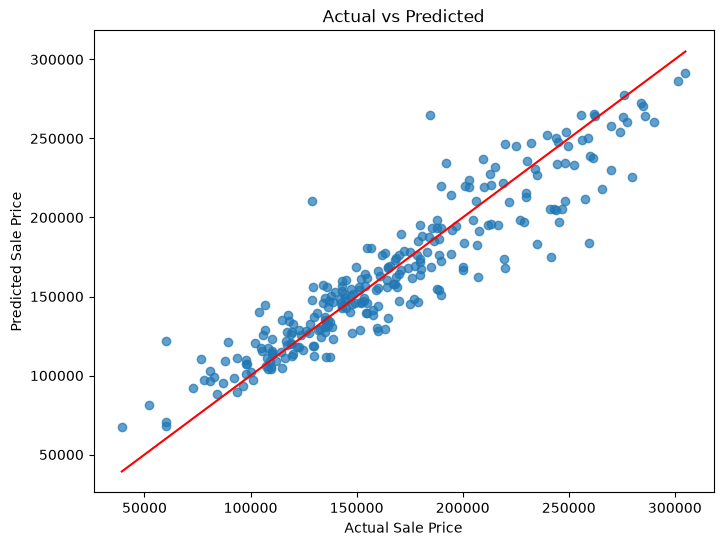

In [34]:
# Actual vs Predicted
plt.figure(figsize=(8,6))

plt.scatter(y_test, prediction, alpha=0.7)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red"
)

plt.xlabel("Actual Sale Price")
plt.ylabel("Predicted Sale Price")
plt.title("Actual vs Predicted")

plt.show()

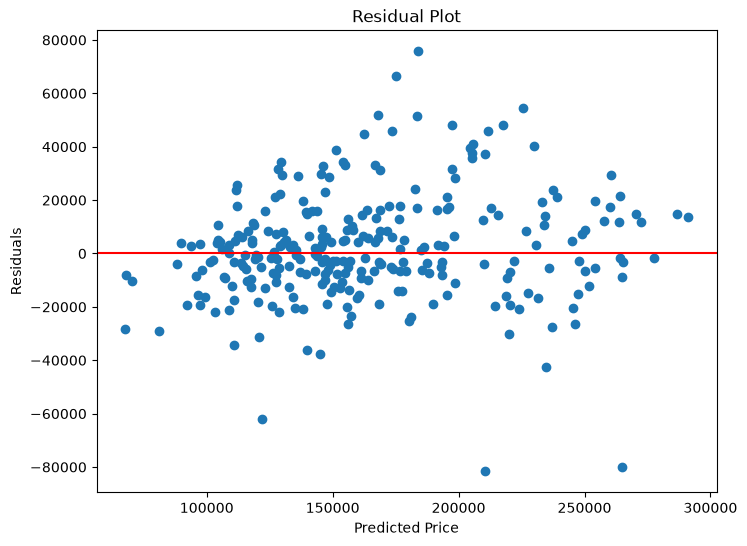

In [35]:
# Residual Plot
residuals = y_test - prediction

plt.figure(figsize=(8,6))

plt.scatter(prediction, residuals)

plt.axhline(0, color="red")

plt.xlabel("Predicted Price")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.show()

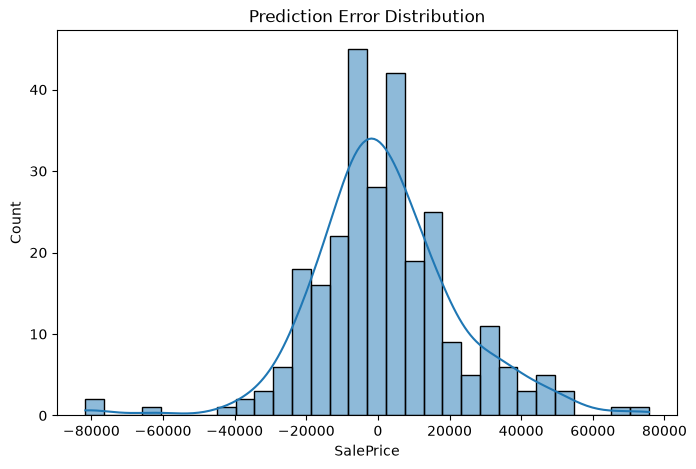

In [36]:
# Prediction Error Distribution
plt.figure(figsize=(8,5))

sns.histplot(residuals, bins=30, kde=True)

plt.title("Prediction Error Distribution")

plt.show()

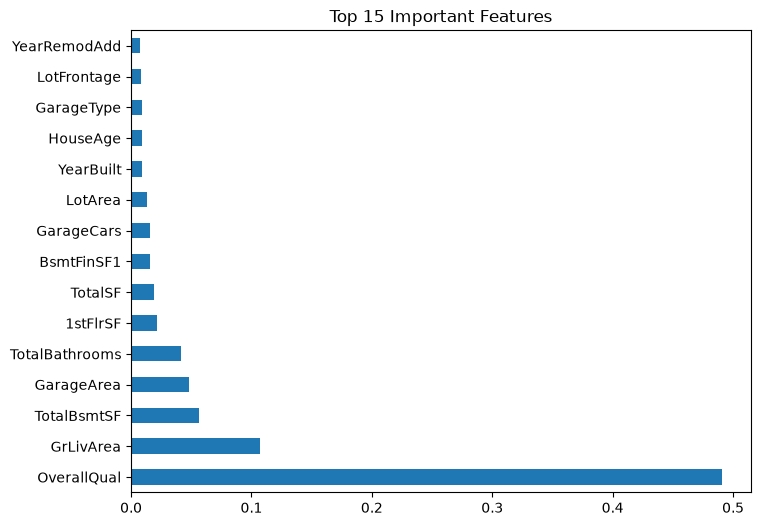

In [37]:
# Feature Importance
importance = pd.Series(
    model.feature_importances_,
    index=X.columns
)

importance.sort_values(ascending=False).head(15).plot(
    kind="barh",
    figsize=(8,6)
)

plt.title("Top 15 Important Features")

plt.show()

In [43]:

comparison = pd.read_csv("/home/aximsoft/Documents/EOWA/Week_08/Notebooks/dataset/reports/model_comparison.csv")

comparison


,Model,MAE,MSE,RMSE,R2 Score
0,CatBoost,11865.448763,2.857276e+08,16903.478657,0.902913
1,Gradient Boosting,13037.290340,3.176112e+08,17821.649295,0.892079
2,LightGBM,12754.447154,3.236428e+08,17990.076343,0.890030
3,XGBoost,14381.427734,3.897360e+08,19741.733257,0.867572
4,Random Forest,14806.264270,4.132783e+08,20329.246246,0.859573
5,Linear Regression,16455.338449,5.674469e+08,23821.143071,0.807188
6,Decision Tree,22355.474453,9.277240e+08,30458.562428,0.684770


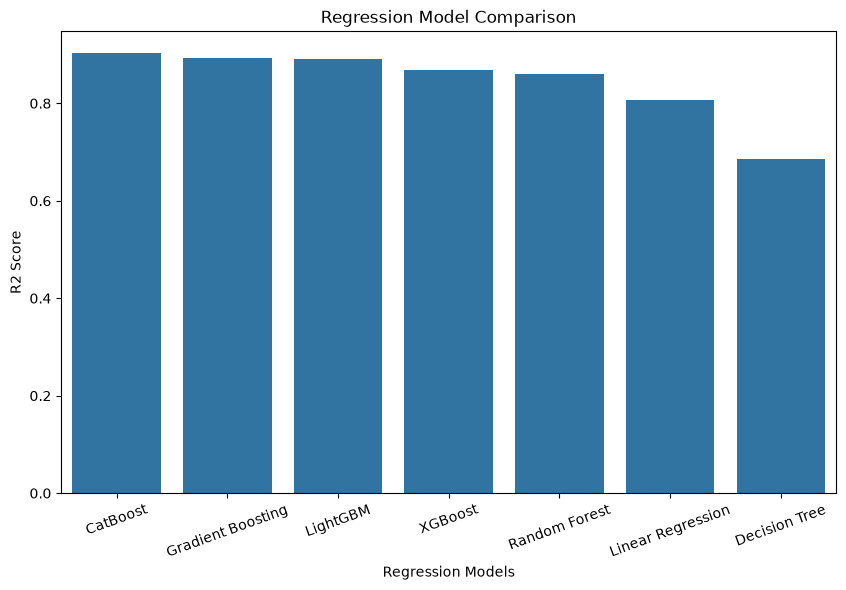

In [44]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=comparison,
    x="Model",
    y="R2 Score"
)

plt.xticks(rotation=20)

plt.title("Regression Model Comparison")

plt.xlabel("Regression Models")
plt.ylabel("R2 Score")

plt.show()

In [39]:
# Best Model
print("Best Model : Random Forest Regressor")
print("R2 Score :", r2)
print("Cross Validation :", score.mean())

Best Model : Random Forest Regressor
R2 Score : 0.8593257273071603
Cross Validation : 0.8581265898379129


# Phase 6 Summary

## Evaluation Metrics

- Mean Absolute Error (MAE)
- Mean Squared Error (MSE)
- Root Mean Squared Error (RMSE)
- R² Score
- Adjusted R²
- Cross Validation Score

## Observations

- The optimized regression model achieved strong predictive performance.
- Actual and predicted values showed a close relationship.
- Residuals were randomly distributed, indicating a good model fit.
- Feature importance analysis identified the most influential variables affecting house prices.
- Model comparison confirmed that the selected model outperformed the other regression algorithms.

## Conclusion

The optimized model demonstrated excellent prediction accuracy and generalization performance. Based on the evaluation metrics and visual analysis, it was selected as the final model for deployment in the Flask web application.